# Fluorescence Data Beispiel

- Während chirurgischer Eingriffe können Nerven vergleichsweise leicht übersehen werden.
- In _Nature Biotechnology_ („Fluorescent Peptides Highlight Peripheral Nerves During Surgery in Mice“, Vol. 29, 2011) wird der Einsatz fluoreszenzmarkierter Peptide beschrieben, die an Nervengewebe binden und so dessen Identifikation erleichtern.
- Ziel ist es, zu untersuchen, ob diese fluoreszierenden Peptide die Erkennung von Nerven während einer Operation unterstützen können.
- Für 12 Mäuse wurde die normierte Fluoreszenzintensität zwei Stunden nach der Verabreichung sowohl für Nervengewebe als auch für Muskelgewebe gemessen.


$H_0:\mu_1=\mu_2$

$H_1:\mu_1>\mu_2$

## Fluorescence Datengrundlage

![title](../img/ex2-1_data.png)

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Nerve": [
        6625, 6000, 5450, 5200, 5175,
        4900, 4750, 4500, 3985, 900,
        450, 2800
    ],
    "Muscle": [
        3900, 3500, 3450, 3200, 2980,
        2800, 2500, 2400, 2200, 1200,
        1150, 1130
    ]
})

df.index+=1
df.index.name = "Observation"

df

,Nerve,Muscle
Observation,,
1,6625,3900
2,6000,3500
3,5450,3450
4,5200,3200
5,5175,2980
6,4900,2800
7,4750,2500
8,4500,2400
9,3985,2200


In [2]:
df_long = df.melt(
    value_vars=["Nerve", "Muscle"],
    var_name="Tissue",
    value_name="Normalized Fluorescence"
)

df_long.head()

,Tissue,Normalized Fluorescence
0,Nerve,6625
1,Nerve,6000
2,Nerve,5450
3,Nerve,5200
4,Nerve,5175


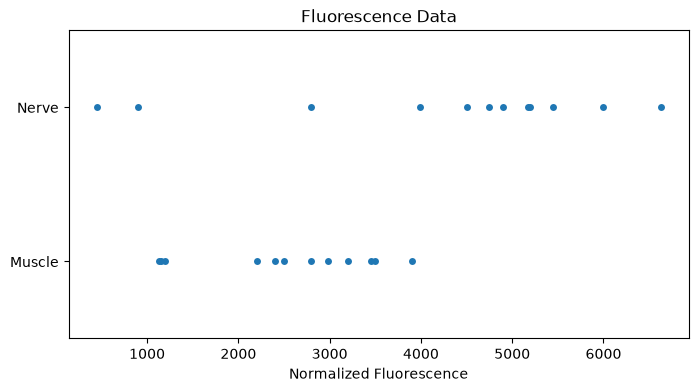

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.stripplot(
    data=df_long,
    x="Normalized Fluorescence",
    y="Tissue",
    jitter=False
)

plt.xlabel("Normalized Fluorescence")
plt.ylabel("")
plt.title("Fluorescence Data")

plt.show()

Aus dem Boxplot wird sofort ersichtlich, dass die Streuungen der beiden Gruppen sehr unterschiedlich sind. 

In diesem Fall wäre die Annahme gleicher Varianzen nicht gerechtfertigt. 

Daher verwenden wir den Welch-ttt-Test, der keine Varianzhomogenität voraussetzt.

# Zweistichproben-$t$-Test bei ungleichen Varianzen

Anstatt eine gemeinsame Varianz zu schätzen, verwenden wir den Welch-$t$-Test, der speziell für Situationen mit unterschiedlichen Streuungen entwickelt wurde. 

Dieser Test ist robuster gegenüber Varianzunterschieden und wird daher bevorzugt eingesetzt, wenn die Annahme homogener Varianzen nicht plausibel erscheint.

In [5]:
import numpy as np
from scipy import stats

x1 = df["Nerve"]
x2 = df["Muscle"]

t_stat, p_value = stats.ttest_ind(
    x1,
    x2,
    equal_var=False,
    alternative="greater"      # oder "less", oder "two-sided"
)

n1, n2 = len(x1), len(x2)
s1, s2 = x1.var(ddof=1), x2.var(ddof=1)

df_welch = (
    (s1/n1 + s2/n2)**2
    /
    (
        ((s1/n1)**2)/(n1-1)
        +
        ((s2/n2)**2)/(n2-1)
    )
)

print("Welch Two-Sample t-Test")
print("-" * 30)
print(f"t-statistic = {t_stat:.3f}")
print(f"df          = {df_welch:.2f}")
print(f"p-value     = {p_value:.4f}")

Welch Two-Sample t-Test
------------------------------
t-statistic = 2.735
df          = 16.19
p-value     = 0.0073


In [6]:
x1 = df["Nerve"]
x2 = df["Muscle"]

mean_diff = x1.mean() - x2.mean()

se = np.sqrt(
    x1.var(ddof=1)/len(x1)
    + x2.var(ddof=1)/len(x2)
)

tcrit = stats.t.ppf(0.975, df_welch)

ci_lower = mean_diff - tcrit * se
ci_upper = mean_diff + tcrit * se

print(f"Mean difference           = {mean_diff:.3f}")
print(f"95% CI                    = ({ci_lower:.3f}, {ci_upper:.3f})")

Mean difference           = 1693.750
95% CI                    = (382.310, 3005.190)


Für den einseitigen Test ist der relevante $p$-Wert 

$p=0.0073$. 

Da dieser unter dem Signifikanzniveau von 5 % liegt, wird die Nullhypothese verworfen. Es gibt somit Evidenz dafür, dass sich die mittleren Fluoreszenzwerte in der erwarteten Richtung unterscheiden.

# Normal probability plot

Der Normal Probability Plot zeigt für beide Gruppen eine annähernd lineare Struktur, sodass die Normalitätsannahme vertretbar erscheint.

Die deutlich unterschiedlichen Steigungen der beiden Geraden weisen jedoch auf ungleiche Varianzen hin. Damit wird die Verwendung des Welch-$t$-Tests gegenüber dem gepoolten Zweistichproben-$t$-Test gerechtfertigt.

Die grafische Untersuchung unterstützt somit die Ergebnisse des vorherigen Hypothesentests.

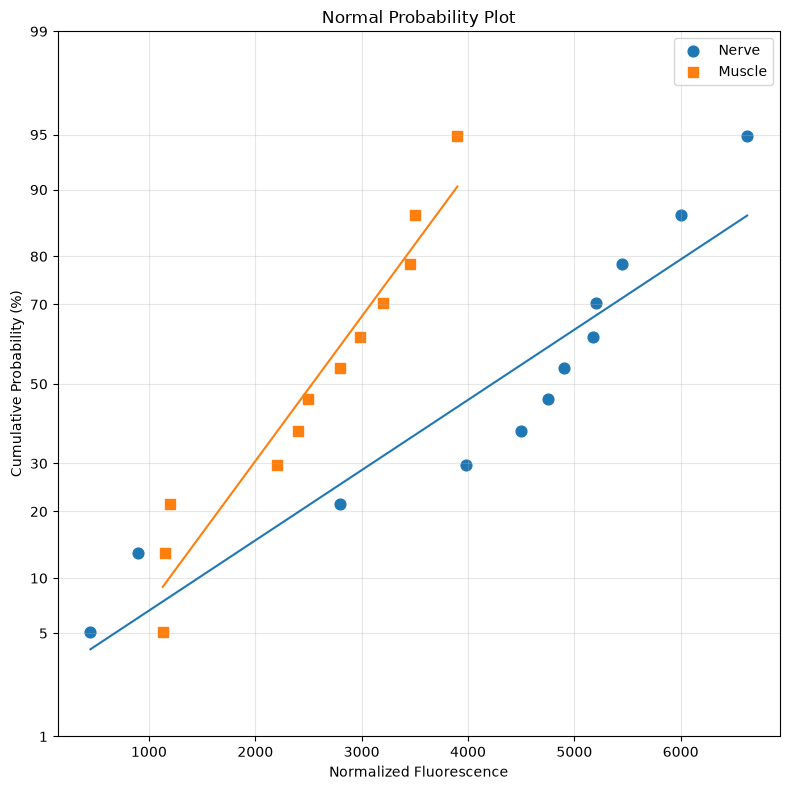

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 8))

for column, marker in [
    ("Nerve", "o"),
    ("Muscle", "s")
]:

    # sortierte Beobachtungen
    x = np.sort(df[column].values)
    n = len(x)

    # Blom plotting positions
    p = (np.arange(1, n + 1) - 0.375) / (n + 0.25)

    # Wahrscheinlichkeit -> Normal-Quantile
    z = stats.norm.ppf(p)

    ax.scatter(
        x,
        z,
        marker=marker,
        s=60,
        label=column.replace("_", " ")
    )

    # Regressionsgerade
    slope, intercept = np.polyfit(x, z, 1)

    xx = np.linspace(x.min(), x.max(), 100)

    ax.plot(
        xx,
        slope * xx + intercept,
        linewidth=1.5
    )

# Wahrscheinlichkeitsskala
prob_ticks = np.array([
    0.01, 0.05, 0.10,
    0.20, 0.30, 0.50,
    0.70, 0.80, 0.90,
    0.95, 0.99
])

ax.set_yticks(stats.norm.ppf(prob_ticks))
ax.set_yticklabels([f"{100*p:.0f}" for p in prob_ticks])

ax.set_xlabel("Normalized Fluorescence")
ax.set_ylabel("Cumulative Probability (%)")
ax.set_title("Normal Probability Plot")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

#plt.savefig("normal_probability_plot.pdf",bbox_inches="tight")
plt.show()
